# Mathematics for Machine Learning: Engineering Revision Notes

## 1. The Nature of Data
Before applying algorithms, we must classify how our system generates data.

* **Random Variable:** A metric where the exact outcome is subject to chance (e.g., the exact `Response_Time` of the next API ping).
* **Discrete Data (Countables):** Data that takes specific, separate values. There are no valid "in-between" states.
  * *Function:* **PMF** (Probability Mass Function) calculates the chance of an exact outcome.
  * *Example:* The number of HTTP 500 errors in an hour.
* **Continuous Data (Measurables):** Data that can take any infinite decimal value within a range.
  * *Function:* **PDF** (Probability Density Function) calculates the probability of a value falling within a specific range.
  * *Example:* The exact memory usage of a Node.js process.
* **CDF (Cumulative Distribution Function):** Calculates the running total probability of getting a value *or anything less than that value*.

---

## 2. Descriptive Statistics (Profiling Data)
Describing the baseline state and spread of an existing dataset.

### Central Tendency (The "Middle")
* **Mean:** The mathematical average. Highly sensitive to outliers.
* **Median:** The exact middle value when sorted. 
  * *Engineering Context:* If an API averages 25ms but has one 1000ms timeout outlier, the median is a more honest representation of typical user experience.

### Dispersion (The "Spread")
* **Variance:** The average of the squared differences from the mean.
* **Standard Deviation:** The square root of the variance, bringing the metric back to original units. Indicates how predictable the system is.
* **Bessel's Correction ($n-1$):** When calculating the variance of a *sample* (logs) rather than a *population* (all historical requests), dividing by $n-1$ prevents underestimating the true real-world fluctuation.
  $$s^2 = \frac{\sum (x_i - \bar{x})^2}{n - 1}$$

### Relationships
* **Covariance:** Indicates the direction of a linear relationship between two variables.
  * *Example:* `Active_Docker_Containers` and `Available_Free_RAM` have a negative covariance (one goes up, the other goes down).
* **Correlation:** Standardizes covariance onto a strict scale from -1.0 to 1.0. Used heavily in feature selection to drop "noisy" metrics that sit near 0.0.

---

## 3. Probability Foundations
How algorithms express confidence about independent events.

* **Addition Rule (OR):** Probability that Event A *or* Event B happens.
* **Multiplication Rule (AND):** Probability that Event A *and* Event B happen together.
  * *Engineering Context:* If Auth Service fails 10% of the time ($0.10$) and DB Service fails 20% of the time ($0.20$), the probability of simultaneous catastrophic failure is $0.10 \times 0.20 = 0.02$ (2%).

---

## 4. Probability Distributions (The Shape of Data)
Mapping the possible outcomes of random variables.

### Discrete Distributions (PMFs)
* **Bernoulli:** A single, isolated event with a binary outcome (1 or 0). 
  * *Example:* Validating a single JWT token.
* **Binomial:** The number of successes in a fixed number of independent trials ($n$).
  * *Example:* Finding the probability of exactly 3 failures out of 100 auth requests, given a known 5% failure rate.
  $$P(X=k) = \binom{n}{k} p^k (1-p)^{n-k}$$
* **Poisson:** Counting discrete events over a fixed amount of time or space, without knowing the total number of trials. Requires only the average rate ($\lambda$).
  * *Example:* Predicting database deadlocks tomorrow when historical average is 4 per day.
  $$P(X=k) = \frac{\lambda^k e^{-\lambda}}{k!}$$

### Continuous Distributions (PDFs)
* **Uniform:** Every value in a range has an equal, flat probability.
  * *Example:* The output of TypeScript's `Math.random()`.
* **Normal (Gaussian):** Perfectly symmetrical bell curve where Mean = Median = Mode. 
* **Standard Normal & Z-Score:** Transforms any normal distribution into a universal scale of "standard deviations away from the mean." Used to normalize metrics with drastically different units.
  * *Example:* A 65ms response time on a 50ms average/5ms standard deviation service yields a Z-score of 3, flagging it as an anomaly.
  $$Z = \frac{x - \mu}{\sigma}$$
* **Log-Normal:** Heavily skewed data that transforms into a perfect Normal Distribution if you apply `Math.log()` to it.
* **Pareto / Power Law:** The "80/20 rule" representing extreme winner-takes-all scenarios. 
  * *Example:* Distribution of social media followers across a user base.

---

## 5. Inferential Statistics (A/B Testing & Decision Making)
Making mathematically backed decisions about an entire system using a small sample.

### Hypothesis Testing
* **Null Hypothesis ($H_0$):** The skeptical default (e.g., "The new load balancing algorithm is equal to or slower than the 50ms baseline").
* **Alternative Hypothesis ($H_1$):** What you are trying to prove (e.g., "The new algorithm is strictly faster than 50ms").
* **P-Value:** The probability of getting your sample results simply by random chance, assuming the Null Hypothesis is true. If $p < \alpha$ (usually 0.05), you reject the Null Hypothesis.

### Evaluation & Errors
* **Type 1 Error (False Positive):** Rejecting the Null Hypothesis when it was actually true (deploying a "faster" algorithm that was just a lucky sample).
* **Type 2 Error (False Negative):** Failing to reject the Null Hypothesis when it was false (throwing away genuinely faster code because of a network lag spike during the test).
* **Confidence Interval:** A statistically safe range for estimates (e.g., "95% confident the true average is between 47ms and 49ms").

### Statistical Tests
* **Z-Test:** Used when sample size is large (>30) and the true population standard deviation is known.
* **T-Test:** Used for small samples where true variance is unknown. Uses the "squashed" Student t-Distribution.
* **ANOVA:** Compares the means of 3 or more continuous groups (e.g., latencies across AWS, GCP, Azure).
* **Chi-Square:** Compares categorical data (e.g., `Operating_System` vs `Auth_Error_State`).

### Bayes Theorem
The mathematical foundation for updating probability predictions based on *new evidence*.
$$P(A|B) = \frac{P(B|A)P(A)}{P(B)}$$

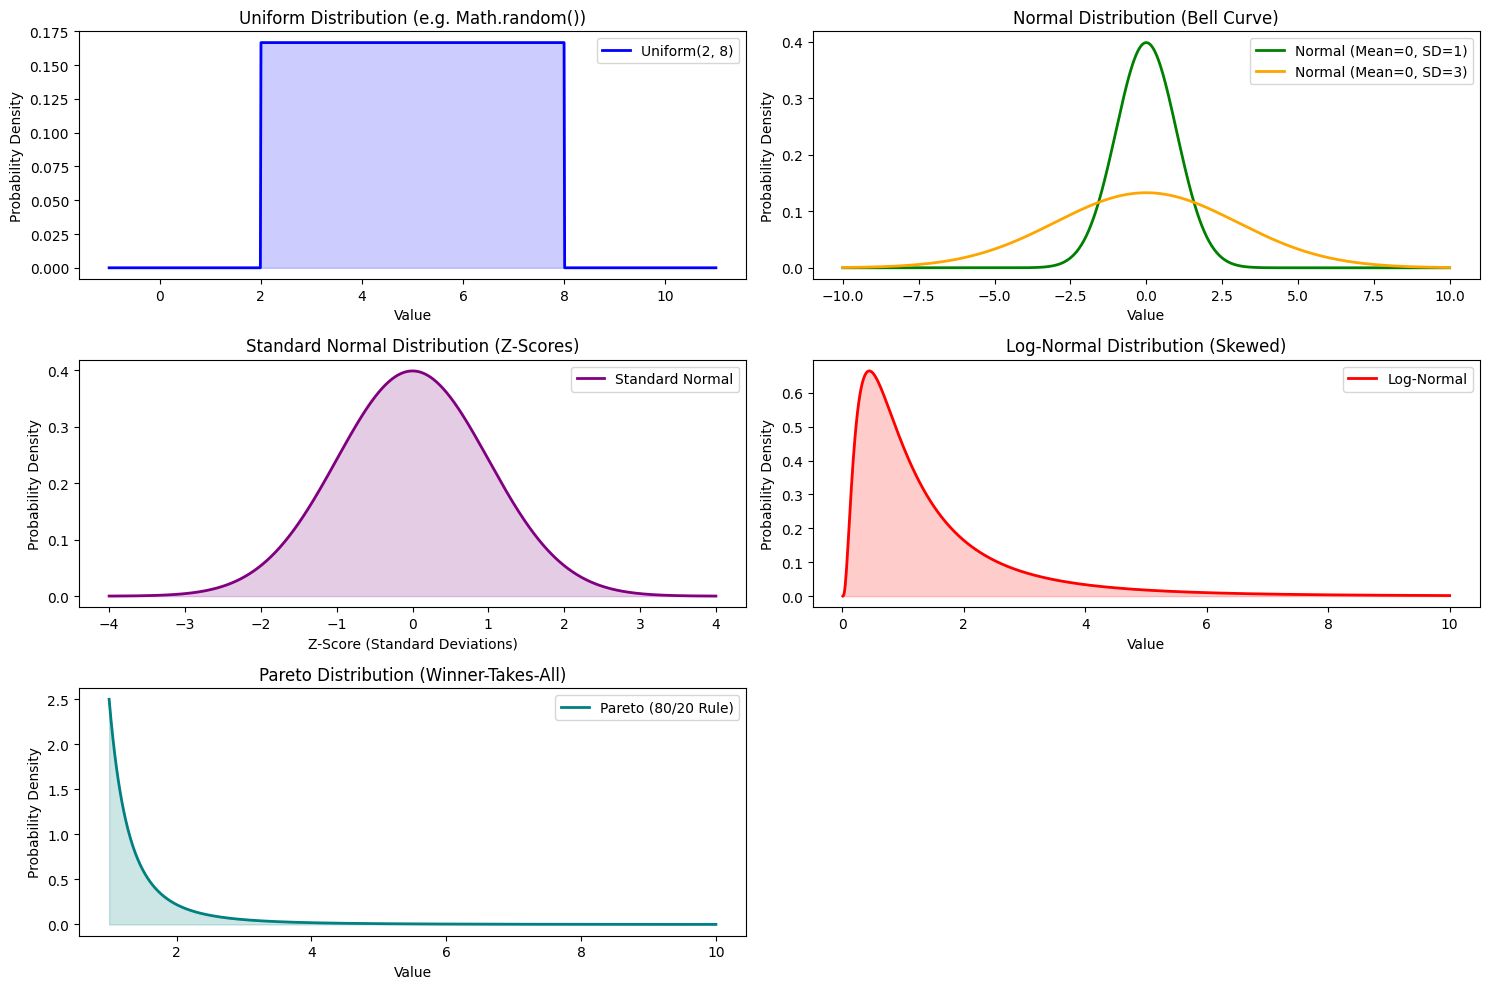

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Set up the figure size for all subplots
plt.figure(figsize=(15, 10))

# ---------------------------------------------------
# 1. Uniform Distribution
# ---------------------------------------------------
plt.subplot(3, 2, 1) # 3 rows, 2 columns, position 1
x_unif = np.linspace(-1, 11, 1000)
# Uniform distribution between 2 and 8 (loc=start, scale=width)
y_unif = stats.uniform.pdf(x_unif, loc=2, scale=6) 
plt.plot(x_unif, y_unif, label='Uniform(2, 8)', color='blue', lw=2)
plt.fill_between(x_unif, y_unif, alpha=0.2, color='blue')
plt.title("Uniform Distribution (e.g. Math.random())")
plt.xlabel("Value")
plt.ylabel("Probability Density")
plt.legend()

# ---------------------------------------------------
# 2. Normal (Gaussian) Distribution
# ---------------------------------------------------
plt.subplot(3, 2, 2)
x_norm = np.linspace(-10, 10, 1000)
# Comparing two normal distributions with different spreads
y_norm1 = stats.norm.pdf(x_norm, loc=0, scale=1) # Mean 0, Std Dev 1
y_norm2 = stats.norm.pdf(x_norm, loc=0, scale=3) # Mean 0, Std Dev 3
plt.plot(x_norm, y_norm1, label='Normal (Mean=0, SD=1)', color='green', lw=2)
plt.plot(x_norm, y_norm2, label='Normal (Mean=0, SD=3)', color='orange', lw=2)
plt.title("Normal Distribution (Bell Curve)")
plt.xlabel("Value")
plt.ylabel("Probability Density")
plt.legend()

# ---------------------------------------------------
# 3. Standard Normal Distribution (Z-Scores)
# ---------------------------------------------------
plt.subplot(3, 2, 3)
x_sn = np.linspace(-4, 4, 1000)
# Standard normal always has Mean=0, Std Dev=1
y_sn = stats.norm.pdf(x_sn, loc=0, scale=1)
plt.plot(x_sn, y_sn, label='Standard Normal', color='purple', lw=2)
plt.fill_between(x_sn, y_sn, alpha=0.2, color='purple')
plt.title("Standard Normal Distribution (Z-Scores)")
plt.xlabel("Z-Score (Standard Deviations)")
plt.ylabel("Probability Density")
plt.legend()

# ---------------------------------------------------
# 4. Log-Normal Distribution
# ---------------------------------------------------
plt.subplot(3, 2, 4)
x_log = np.linspace(0.01, 10, 1000)
# s is the shape parameter (standard deviation of the underlying normal distribution)
y_log = stats.lognorm.pdf(x_log, s=0.9, scale=np.exp(0))
plt.plot(x_log, y_log, label='Log-Normal', color='red', lw=2)
plt.fill_between(x_log, y_log, alpha=0.2, color='red')
plt.title("Log-Normal Distribution (Skewed)")
plt.xlabel("Value")
plt.ylabel("Probability Density")
plt.legend()

# ---------------------------------------------------
# 5. Pareto (Power Law) Distribution
# ---------------------------------------------------
plt.subplot(3, 2, 5)
x_par = np.linspace(1, 10, 1000)
# b is the shape parameter
y_par = stats.pareto.pdf(x_par, b=2.5)
plt.plot(x_par, y_par, label='Pareto (80/20 Rule)', color='teal', lw=2)
plt.fill_between(x_par, y_par, alpha=0.2, color='teal')
plt.title("Pareto Distribution (Winner-Takes-All)")
plt.xlabel("Value")
plt.ylabel("Probability Density")
plt.legend()

# Adjust layout to prevent overlap and display
plt.tight_layout()
plt.show()